In [1]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.seed import set_seed
from src.pipeline.missing_value import CJ_MissingValue, JH_MissingValue, JH_train_stats
from src.pipeline.outlier_control import OutlierControl

In [2]:
df_raw = pd.read_excel('../data/dataset.xlsx')
train_idx, test_idx = train_test_split(
    df_raw.index,
    test_size=0.2,
    random_state=42,
    stratify=df_raw['Churn'],
)
df_train = df_raw.loc[train_idx].copy()
df_test = df_raw.loc[test_idx].copy()
print('train', len(df_train), 'test', len(df_test))
df_train.info()

train 4504 test 1126
<class 'pandas.core.frame.DataFrame'>
Index: 4504 entries, 1787 to 5140
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   4504 non-null   int64  
 1   Churn                        4504 non-null   int64  
 2   Tenure                       4291 non-null   float64
 3   PreferredLoginDevice         4504 non-null   object 
 4   CityTier                     4504 non-null   int64  
 5   WarehouseToHome              4298 non-null   float64
 6   PreferredPaymentMode         4504 non-null   object 
 7   Gender                       4504 non-null   object 
 8   HourSpendOnApp               4307 non-null   float64
 9   NumberOfDeviceRegistered     4504 non-null   int64  
 10  PreferedOrderCat             4504 non-null   object 
 11  SatisfactionScore            4504 non-null   int64  
 12  MaritalStatus                4504 non-null   object 
 13 

In [3]:

CJ_SPECS = (
    ("Tenure", "NumberOfAddress", 5),
    ("DaySinceLastOrder", ["PreferedOrderCat", "PreferredLoginDevice"], 10),
    ("OrderCount", ["PreferedOrderCat", "PreferredPaymentMode"], 10),
    ("OrderAmountHikeFromlastYear", "PreferedOrderCat", 3),
)

for column_name, group_by_columns, minimum_group_size in CJ_SPECS:
    # 이 컬럼 전체의 중앙값 (작은 그룹일 때 쓰는 기본값)
    median_of_entire_train = df_train[column_name].median()

    CJ_MissingValue(
        df_train,
        col=column_name,
        group_cols=group_by_columns,
        min_group_size=minimum_group_size,
        train_median=median_of_entire_train,
        test_df=df_test,
    )

# 결측 JH: train에서만 통계 계산 → train·test 동일 인자로 채움
jh_stats = JH_train_stats(df_train)

for dataframe in (df_train, df_test):
    JH_MissingValue(dataframe, **jh_stats)



In [4]:
# 이상치 처리 (train/test 각각)
cols=['Tenure','WarehouseToHome','DaySinceLastOrder','CashbackAmount']
OutlierControl(df_train, cols)
OutlierControl(df_test, cols)




,CustomerID,Churn,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,Tenure_log,WarehouseToHome_log,DaySinceLastOrder_clip,CashbackAmount_clip
4006,54007,0,Computer,3,Debit Card,Male,4.0,4,Laptop & Accessory,1,Married,3,0,21.0,6.0,8.0,2.890372,2.302585,8.0,181.75
1969,51970,0,Mobile Phone,3,E wallet,Female,3.0,4,Fashion,1,Married,8,1,18.0,0.0,1.0,3.295837,2.639057,3.0,209.34
4235,54236,0,Mobile Phone,1,Debit Card,Female,4.0,4,Laptop & Accessory,1,Single,3,0,24.0,2.0,2.0,1.791759,2.772589,9.0,169.24
105,50106,0,Phone,1,Debit Card,Female,2.0,4,Mobile,2,Single,8,0,15.0,0.0,2.0,3.258097,2.197225,2.0,132.12
2295,52296,0,Computer,3,Debit Card,Female,2.0,3,Fashion,3,Married,2,1,19.0,8.0,9.0,1.609438,2.197225,6.0,198.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4362,54363,0,Computer,1,Credit Card,Male,3.0,4,Mobile Phone,3,Married,3,1,18.0,3.0,3.0,2.197225,2.890372,1.0,163.15
2487,52488,0,Mobile Phone,1,Credit Card,Female,2.0,5,Laptop & Accessory,5,Single,2,1,14.0,0.0,1.0,2.944439,2.484907,4.0,157.69
5063,55064,0,Mobile Phone,1,Debit Card,Male,3.0,4,Laptop & Accessory,1,Married,3,1,12.0,2.0,2.0,1.386294,2.708050,1.0,191.23
1958,51959,0,Phone,2,UPI,Male,2.0,3,Mobile Phone,1,Married,1,0,19.0,1.0,1.0,2.079442,2.302585,2.0,137.37


In [5]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4504 entries, 1787 to 5140
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   4504 non-null   int64  
 1   Churn                        4504 non-null   int64  
 2   PreferredLoginDevice         4504 non-null   object 
 3   CityTier                     4504 non-null   int64  
 4   PreferredPaymentMode         4504 non-null   object 
 5   Gender                       4504 non-null   object 
 6   HourSpendOnApp               4504 non-null   float64
 7   NumberOfDeviceRegistered     4504 non-null   int64  
 8   PreferedOrderCat             4504 non-null   object 
 9   SatisfactionScore            4504 non-null   int64  
 10  MaritalStatus                4504 non-null   object 
 11  NumberOfAddress              4504 non-null   int64  
 12  Complain                     4504 non-null   int64  
 13  OrderAmountHikeFroml

In [6]:
import pandas as pd
import numpy as np

def FeatureCreate(df, train_monthly_freq_mean=None):
    df = df.copy()

    actual_tenure = np.expm1(df['Tenure_log']).clip(lower=0.1)
    # 계산 편의를 위한 변수 설정 (나눗셈 시 0 방지를 위해 +1 처리)
    order_cnt = df['OrderCount']
    denom_order = order_cnt + 1
    # 평균 주문 주기: 전체 가입 기간 중 얼마나 자주 주문했는지 시간 간격 계산
    avg_interval = (actual_tenure / denom_order).clip(lower=0.1)

    # 1. (이탈의 핵심 징후 포착)
    # Dormancy_Shock: 평소 주기 대비 이번 공백기가 얼마나 '충격적'으로 긴지 (값 클수록 위험)
    df['Dormancy_Shock'] = df['DaySinceLastOrder_clip'] / (avg_interval + 1)
    # Recency_Tenure_Ratio: 가입 기간 대비 공백기 비중 (신규 고객의 이탈 가능성 포착)
    df['Recency_Tenure_Ratio'] = df['DaySinceLastOrder_clip'] / actual_tenure
    # MonthlyOrderFreq: 월평균 주문 빈도 (고객의 활동성 수준)
    df['MonthlyOrderFreq'] = order_cnt / actual_tenure
    
    # 2. 경험 및 심리 지표
    # IssueIndex: 불만 제기 여부 (명시적인 부정적 경험)
    df['IssueIndex'] = df['Complain'].astype(int)
    # Satisfaction_Per_Order: 주문 횟수 대비 체감 만족도 효율
    df['Satisfaction_Per_Order'] = df['SatisfactionScore'] / denom_order
    # Silent_Killer: 불만은 없으나 만족도가 낮은 '조용한 이탈자' 후보군 식별
    df['Silent_Killer'] = ((df['IssueIndex'] == 0) & (df['SatisfactionScore'] <= 2)).astype(int)
    
    # 3. 혜택 및 효율 지표
    # CashbackPerOrder: 주문 건당 평균 캐시백 혜택 체감도
    df['CashbackPerOrder'] = df['CashbackAmount_clip'] / denom_order
    # Promo_Sensitivity: 주문 대비 쿠폰 사용 빈도 (프로모션 민감도)
    df['Promo_Sensitivity'] = df['CouponUsed'] / denom_order

    # 4. 세그먼트 및 행동 플래그
    # Train 데이터의 평균 빈도를 기준으로 현재 데이터의 활동 정체 여부 판단 
    if train_monthly_freq_mean is not None:
        _mean_mof = train_monthly_freq_mean
    else:
        _mean_mof = df['MonthlyOrderFreq'].mean()
        
    # Stagnant_Loyal: 가입은 오래됐으나 활동이 평균 이하로 떨어진 '정체된 충성 고객'
    df['Stagnant_Loyal'] = ((actual_tenure >= 30) & (df['MonthlyOrderFreq'] < _mean_mof)).astype(int)
    # ManyAddressesFlag: 배송지 주소가 많음 (서비스 활용 반경이 넓은 헤비 유저 여부)
    df['ManyAddressesFlag'] = (df['NumberOfAddress'] >= 3).astype(int)

    # 6. 범주형 변수 처리 
    cat_cols = ['PreferredLoginDevice', 'PreferedOrderCat', 'MaritalStatus', 'Gender']
    available_cats = [c for c in cat_cols if c in df.columns]
    df = pd.get_dummies(df, columns=available_cats, drop_first=True)

    drop_cols = [
        'DaySinceLastOrder_clip', 'Complain', 'SatisfactionScore', 
        'CashbackAmount_clip', 'OrderCount', 'CouponUsed', 
        'WarehouseToHome_log', 'RecentActive', 'HourSpendOnApp',
        'is_newbie_risk', 'RoughLTV', 'PreferredPaymentMode'
    ]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    # Boolean 타입을 0/1 정수형으로 최종 변환
    bool_cols = df.select_dtypes(include=['bool']).columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df


In [7]:
df_train = FeatureCreate(df_train)
_mof_mean = df_train['MonthlyOrderFreq'].mean()
df_test = FeatureCreate(df_test, train_monthly_freq_mean=_mof_mean)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

class FeatureValidator:
    def __init__(self, df, target='Churn', drop_cols=['CustomerID']):
        self.df = df.copy()
        self.target = target
        # 학습에 방해되는 비수치형 및 drop_cols 제외
        self.X = self.df.drop(columns=[target] + drop_cols, errors='ignore').select_dtypes(include=[np.number])
        self.y = self.df[target]

    def check_correlation(self, top_n=15):
        """1. 타겟 변수와의 상관관계 분석 (바차트)"""
        print(f"\n[1] Top {top_n} Correlations with {self.target}")
        corr_matrix = self.df.corr()
        top_corr = corr_matrix[self.target].abs().sort_values(ascending=False).head(top_n+1)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_corr.values[1:], y=top_corr.index[1:])
        plt.title(f"Top {top_n} Features Correlated with {self.target}")
        plt.show()

    def plot_heatmap(self, top_n=20):
        """2. 상관관계 히트맵 출력"""
        print(f"\n[2] Correlation Heatmap (Top {top_n} Features)")
        correlations = self.df.corr()[self.target].abs().sort_values(ascending=False)
        top_features = correlations.head(top_n).index
        top_corr_matrix = self.df[top_features].corr()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
        plt.title(f"Top {top_n} Features Correlation Heatmap")
        plt.show()

    def check_vif(self, thresh=15):
        """3. 다중공선성(VIF) 분석"""
        print(f"\n[3] High VIF Features (Threshold > {thresh})")
        vif_data = pd.DataFrame()
        vif_data["feature"] = self.X.columns
        vif_data["VIF"] = [variance_inflation_factor(self.X.values, i) for i in range(len(self.X.columns))]
        
        high_vif = vif_data[vif_data['VIF'] > thresh].sort_values(by="VIF", ascending=False)
        if high_vif.empty:
            print(f"모든 피처의 VIF가 {thresh} 미만으로 정상 범위 내에 있습니다.")
        else:
            print(high_vif)
        return vif_data

    def plot_distribution_analysis(self, features=['Dormancy_Shock', 'Recency_Tenure_Ratio']):
        """5. 주요 피처별 타겟(이탈/유지) 분포 비교 (KDE Plot)"""
        print(f"\n[5] Target-wise Distribution Analysis")
        
        # 실제 데이터에 존재하는 피처만 필터링
        valid_features = [f for f in features if f in self.df.columns]
        n_features = len(valid_features)
        
        if n_features == 0:
            print("분석할 피처가 데이터프레임에 존재하지 않습니다.")
            return

        fig, axes = plt.subplots(n_features, 1, figsize=(10, 5 * n_features))
        if n_features == 1: axes = [axes]
        
        for i, col in enumerate(valid_features):
            sns.kdeplot(data=self.df, x=col, hue=self.target, fill=True, common_norm=False, ax=axes[i], palette='Set1')
            axes[i].set_title(f"Distibution of {col} (Churn vs. Stay)")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Density")
        
        plt.tight_layout()
        plt.show()

    def run_all(self):
        """모든 검증 및 분석 로직 통합 실행"""
        self.check_correlation()
        self.plot_heatmap()
        self.check_vif()
        self.plot_distribution_analysis()


[1] Top 15 Correlations with Churn


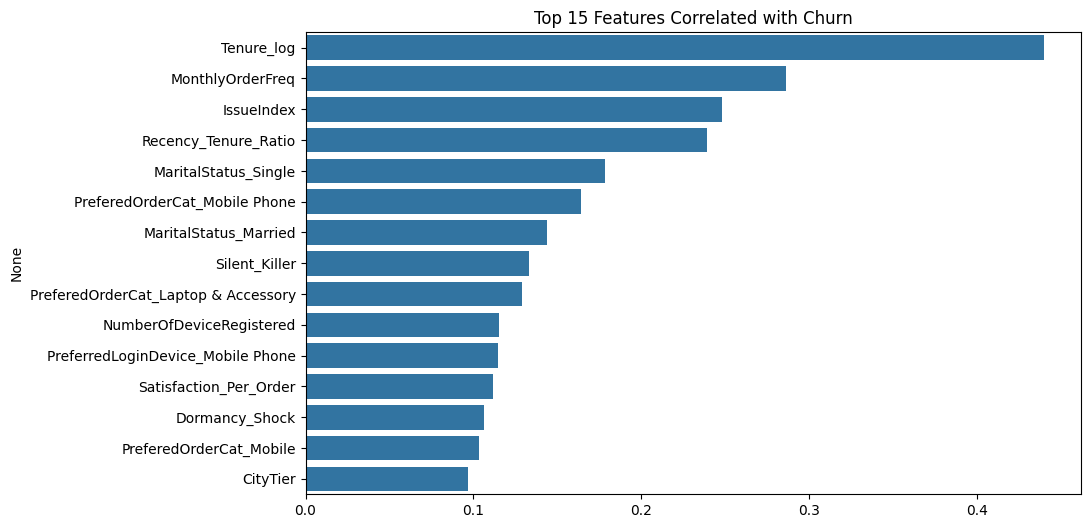


[2] Correlation Heatmap (Top 20 Features)


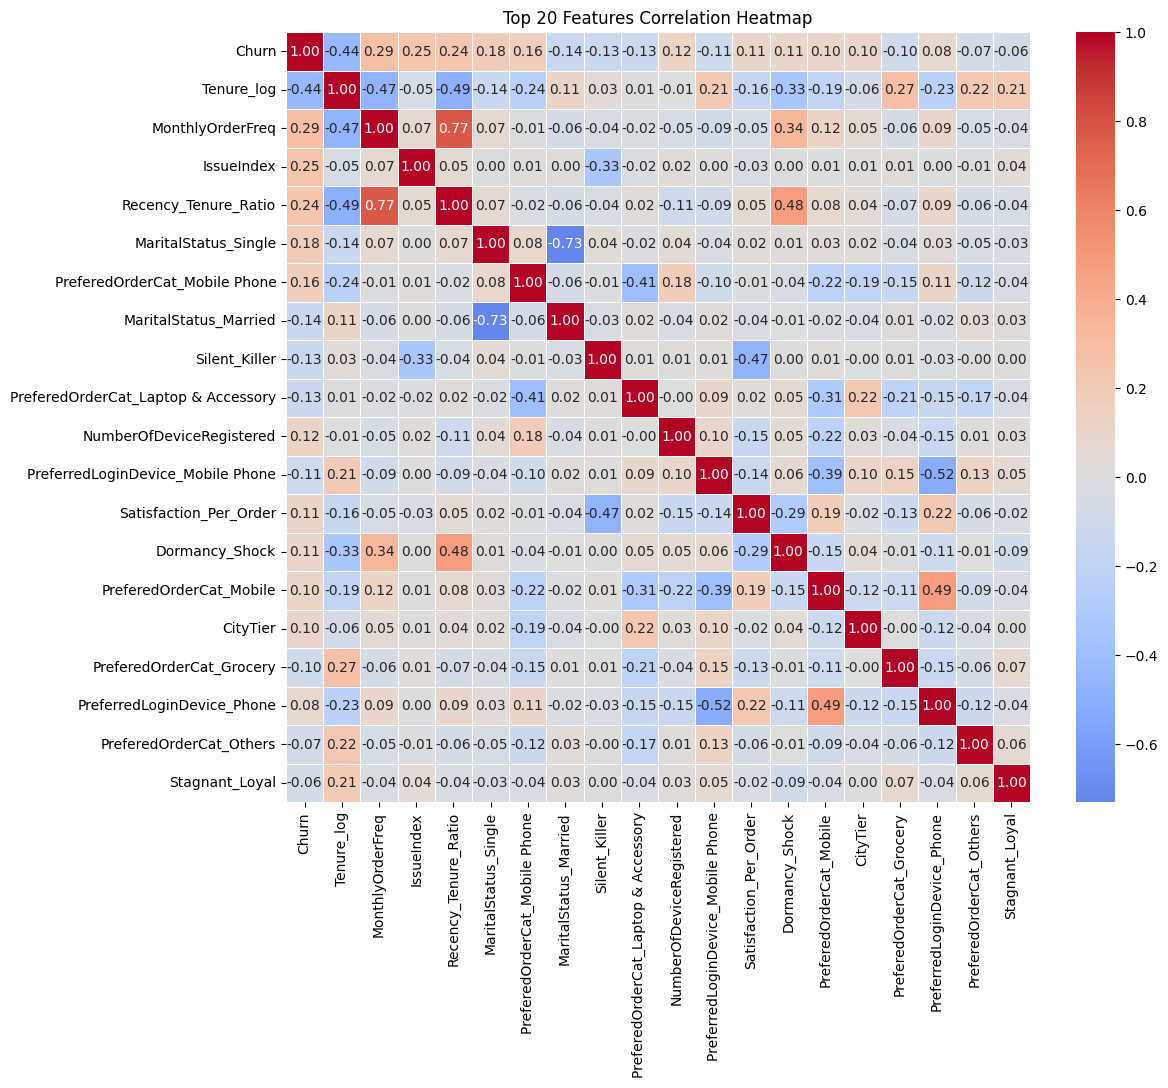


[3] High VIF Features (Threshold > 15)
                        feature        VIF
3   OrderAmountHikeFromlastYear  17.106067
11             CashbackPerOrder  15.555095

[5] Target-wise Distribution Analysis


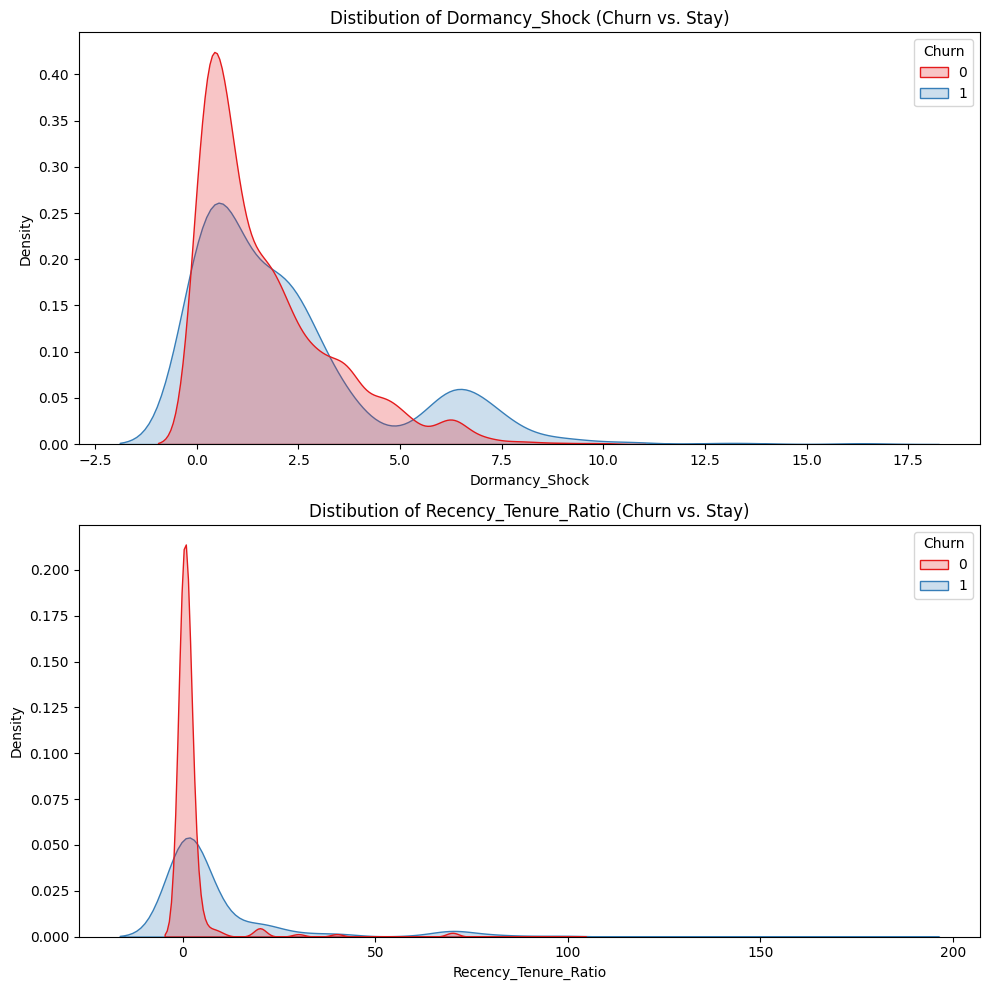

In [9]:
# 위에서 만든 클래스 불러오기 (혹은 같은 파일 내 작성)
validator = FeatureValidator(df_train)

# 모든 리포트 출력
validator.run_all()